All modeling libraries imported successfully.
Training Set Shape: (227845, 31) | Fraud Cases: 394
Testing Set Shape:  (56962, 31)  | Fraud Cases: 98

Training Random Forest Classifier...

Training Random Forest Classifier...
Training XGBoost Classifier...

 PERFORMANCE METRICS: RANDOM FOREST
Precision : 0.6587 (Of all flagged transactions, how many were true fraud?)
Recall    : 0.8469 (Of all actual fraud, how many did we successfully detect?)
F1-Score  : 0.7411 (Harmonic mean balancing Precision and Recall)
PR-AUC    : 0.8245 (Area under the Precision-Recall curve)

 PERFORMANCE METRICS: XGBOOST
Precision : 0.7736 (Of all flagged transactions, how many were true fraud?)
Recall    : 0.8367 (Of all actual fraud, how many did we successfully detect?)
F1-Score  : 0.8039 (Harmonic mean balancing Precision and Recall)
PR-AUC    : 0.8677 (Area under the Precision-Recall curve)


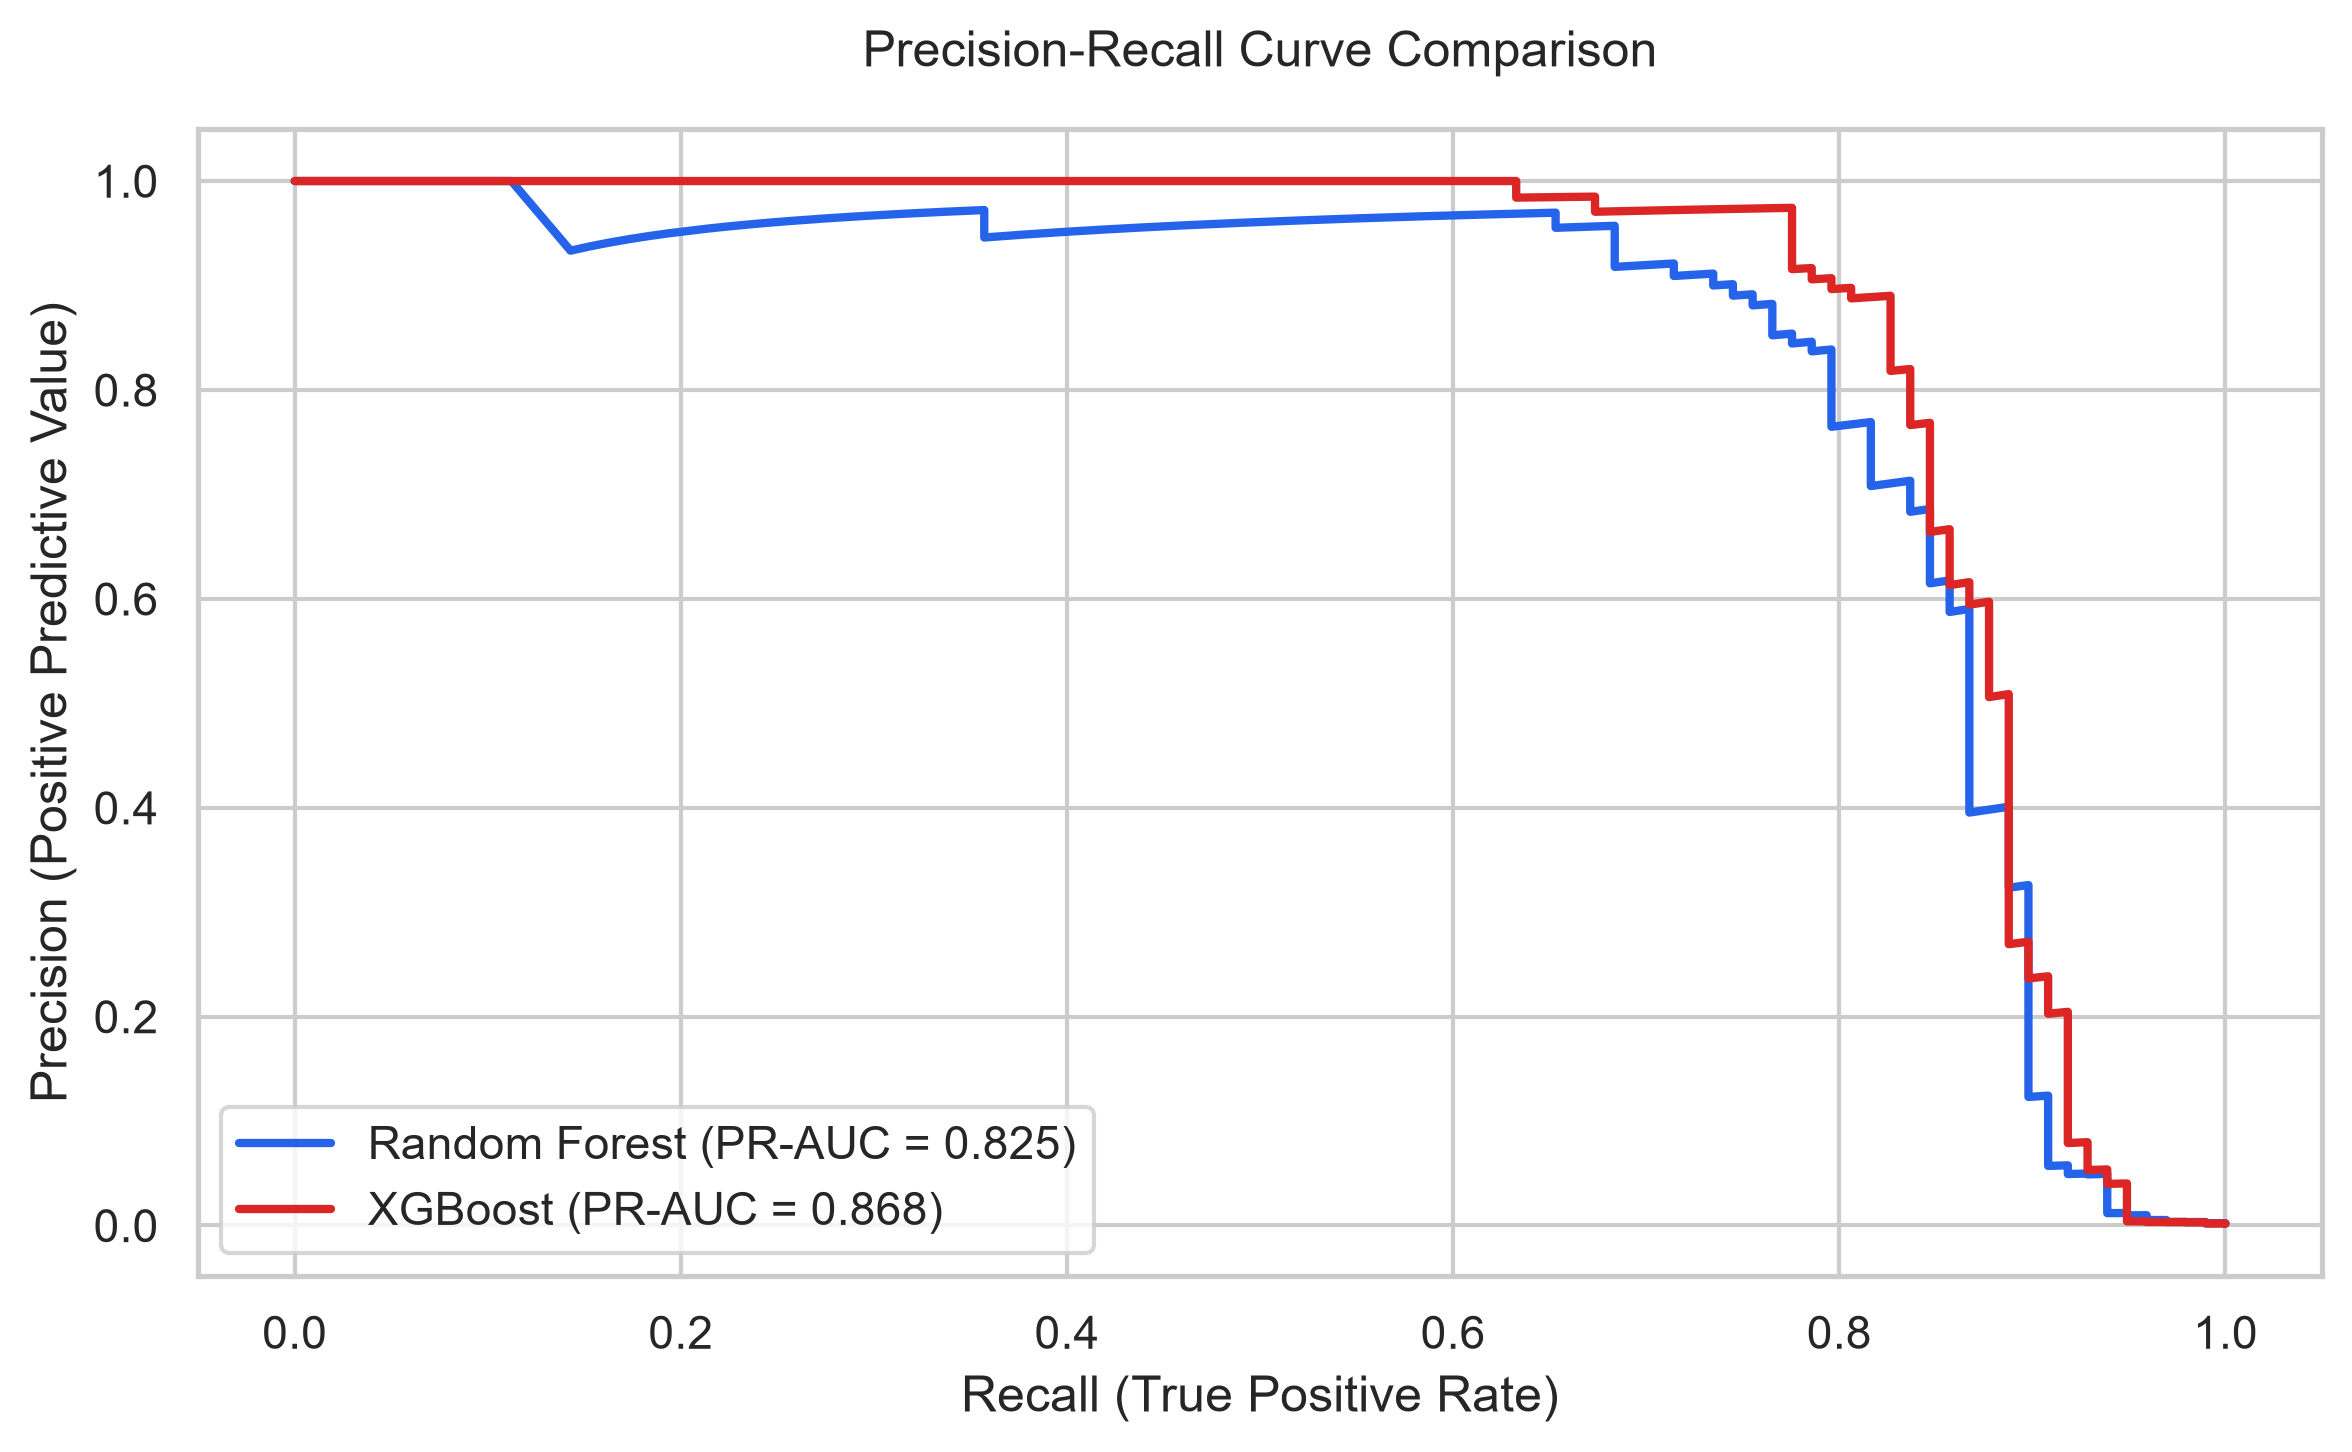

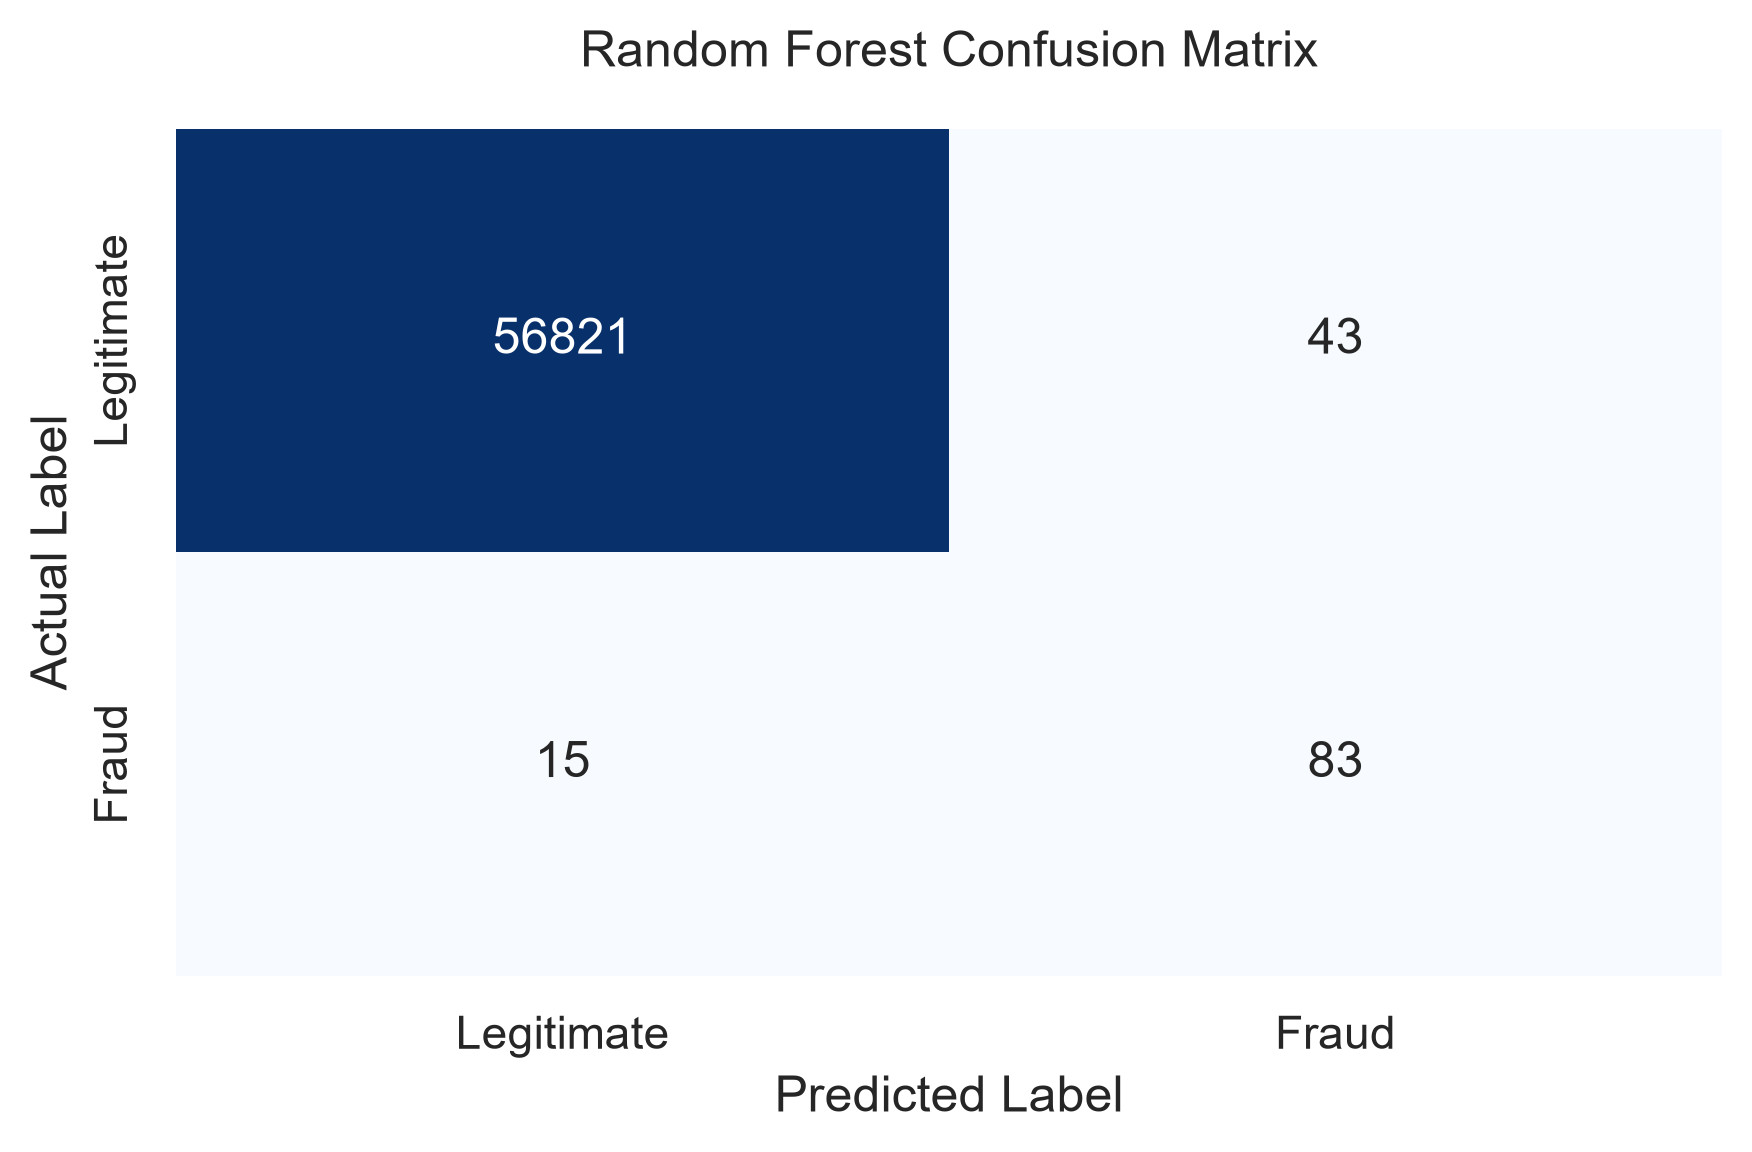

In [4]:
#----------------------------------------------------------------------------
# 1. Import necessary libraries & Environment Setup
#----------------------------------------------------------------------------
# RATIONALE: Import sqlite3 to extract the transformed dataset directly from your 
# data warehouse. This maintains continuity with your modular ETL pipeline.
import sqlite3

# RATIONALE: Pandas and NumPy for matrix manipulation, array indexing, and metrics formatting.
import pandas as pd
import numpy as np

# RATIONALE: Scikit-learn data splitting and model evaluation utilities.
# StratifiedKFold and train_test_split are crucial for preserving class ratios.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    auc,
    average_precision_score
)

# RATIONALE: Import XGBoost for advanced gradient boosting comparison.
# Note: Install via 'pip install xgboost' if not present in your virtual environment.
import xgboost as xgb

# RATIONALE: Visualisation libraries to render Precision-Recall Curves and Confusion Matrices.
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic for publication-ready figures
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 300

print("All modeling libraries imported successfully.")

#----------------------------------------------------------------------------
# 2. Data Loading and Preprocessing
#----------------------------------------------------------------------------
# RATIONALE: Load transformed dataset directly from the SQLite Data Warehouse.
db_path = "../data/processed/fraud_warehouse.db"
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM cleaned_transactions", conn)
conn.close()

# Separate explanatory features (X) from the target label (y)
X = df.drop(columns=['Class'])
y = df['Class']

# RATIONALE: Stratified Train-Test Split (80% Train, 20% Test).
# CRITICAL DECISION: The 'stratify=y' parameter forces the exact 0.17% fraud ratio to be 
# preserved across both training and test sets. Without stratification, random sampling 
# risks placing too few (or zero) fraud cases in the test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training Set Shape: {X_train.shape} | Fraud Cases: {y_train.sum()}")
print(f"Testing Set Shape:  {X_test.shape}  | Fraud Cases: {y_test.sum()}")


# ==============================================================================
# 3. MODEL SELECTION & TRAINING
# ==============================================================================

# ------------------------------------------------------------------------------
# MODEL TYPE A: RANDOM FOREST CLASSIFIER
# ------------------------------------------------------------------------------
# RATIONALE: Random Forest builds an ensemble of decision trees using bagging (bootstrap 
# aggregating). It is robust against overfitting, non-linear feature interactions, and outliers.
# CRITICAL DECISION: 'class_weight="balanced"' automatically adjusts weights inversely 
# proportional to class frequencies, forcing trees to pay higher penalty for misclassifying fraud.

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # RATIONALE: Use all available CPU cores for fast parallel processing
)

print("\nTraining Random Forest Classifier...")
rf_model.fit(X_train, y_train)
#----------------------------------------------------------------------------
# 3. Model Selection, Training
#----------------------------------------------------------------------------

#----------------------------------------------------------------------------
# 3A. MODEL TYPE A: Random Forest Classifier
#----------------------------------------------------------------------------
# RATIONALE: Random Forest builds an ensemble of decision trees using bagging (bootstrap 
# aggregating). It is robust against overfitting, non-linear feature interactions, and outliers.
# CRITICAL DECISION: 'class_weight="balanced"' automatically adjusts weights inversely 
# proportional to class frequencies, forcing trees to pay higher penalty for misclassifying fraud.

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # RATIONALE: Use all available CPU cores for fast parallel processing
)

print("\nTraining Random Forest Classifier...")
rf_model.fit(X_train, y_train)

#----------------------------------------------------------------------------
# 3B. MODEL TYPE B: XGBoost Classifier
#----------------------------------------------------------------------------
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost Classifier...")
xgb_model.fit(X_train, y_train)
#----------------------------------------------------------------------------
# 4. Model Evaluation
#----------------------------------------------------------------------------

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    RATIONALE: Custom evaluation function focused on imbalanced metrics.
    Avoids raw Accuracy, which is misleading when 99.83% of data belongs to one class.
    """
    # Predict discrete binary class (0 or 1)
    y_pred = model.predict(X_test)
    
    # Predict continuous probability scores for the positive class (Fraud = 1)
    # Required for Precision-Recall Curve calculation
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate imbalanced metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Compute Precision-Recall Curve points and Area Under Curve (PR-AUC)
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recalls, precisions)
    
    print(f"\n==================================================")
    print(f" PERFORMANCE METRICS: {model_name.upper()}")
    print(f"==================================================")
    print(f"Precision : {precision:.4f} (Of all flagged transactions, how many were true fraud?)")
    print(f"Recall    : {recall:.4f} (Of all actual fraud, how many did we successfully detect?)")
    print(f"F1-Score  : {f1:.4f} (Harmonic mean balancing Precision and Recall)")
    print(f"PR-AUC    : {pr_auc:.4f} (Area under the Precision-Recall curve)")
    
    return {
        'name': model_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'pr_auc': pr_auc,
        'precisions': precisions,
        'recalls': recalls,
        'y_pred': y_pred
    }

# Evaluate both trained models
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

#----------------------------------------------------------------------------
# 5. Visualiation of Results
#----------------------------------------------------------------------------
# RATIONALE: Plot Precision-Recall Curves. Unlike ROC curves (which mask performance 
# on highly imbalanced data due to large True Negative counts), PR Curves explicitly 
# evaluate the trade-off between False Positives and False Negatives.

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(rf_results['recalls'], rf_results['precisions'], label=f"Random Forest (PR-AUC = {rf_results['pr_auc']:.3f})", color='#2563eb', linewidth=2)
ax.plot(xgb_results['recalls'], xgb_results['precisions'], label=f"XGBoost (PR-AUC = {xgb_results['pr_auc']:.3f})", color='#dc2626', linewidth=2)

ax.set_title("Precision-Recall Curve Comparison", pad=15)
ax.set_xlabel("Recall (True Positive Rate)")
ax.set_ylabel("Precision (Positive Predictive Value)")
ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig("../docs/precision_recall_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# RATIONALE: Plot Confusion Matrix for top performing model (Random Forest)
cm = confusion_matrix(y_test, rf_results['y_pred'])
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])

plt.title("Random Forest Confusion Matrix", pad=15)
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("../docs/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()